# The Choppiness Index — a quantitative teardown 🔬
### Mechanical trailing CI on 5 indices · low-CI-onset forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a return-shuffled structure placebo · costs · a synthetic planted-momentum control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Forecasts_trend_vs_chop%3F: Busted](https://img.shields.io/badge/Forecasts_trend_vs_chop%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **gauge** from the **drift**: an upward-trending index makes *any* long entry look good, so the only meaningful test is low-CI-vs-random, plus a placebo that destroys the CI's trend-vs-chop structure while preserving its marginals.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. CI is trailing-only (N=14, low-CI threshold 38.2); entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from choppiness_index import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real choppiness cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 936, 'window': 14, 'low': 38.2, 'fp_spy': '4cb5244f3990', 'h5': (5, 936, 45.4, 60, 5.25, 27.7, 17.7, 43.4, 1.54, 0.124), 'h10': (10, 936, 61.5, 63, 5.07, 61.2, 0.3, 59.5, 0.02, 0.983), 'h20': (20, 935, 106.7, 63, 5.56, 114.4, -7.7, 104.7, -0.33, 0.741), 'h60': (60, 928, 293.8, 68, 7.93, 250.1, 43.8, 291.8, 1.15, 0.25), 'per': [('SPY', 182, 84.3, 2.36, 105.0, -20.7), ('QQQ', 186, 101.8, 1.88, 144.8, -43.0), ('IWM', 153, 99.8, 1.82, 99.5, 0.3), ('DIA', 184, 128.4, 5.01, 96.4, 32.0), ('GLD', 231, 115.5, 2.78, 121.7, -6.1)], 'placebo': (84.3, 0.409, 500), 'syn': [(0.0, 80, 63.5, 57, 1.12), (0.35, 84, 871.0, 79, 7.47)]}


real choppiness cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Low-CI onset vs a **drift-matched random** baseline: the difference is tiny (Δ = +18/+0/-8/+44 bps at 5/10/20/60d) and the low-CI-minus-random Welch *t* **never clears 2** (max +1.54 at 5d, *p* = 0.124). |
| **Tradability** | `MIRAGE` | The big one-sample t's (20d t = 5.56, 60d t = 7.93) are **pure beta** — they vanish against random entries and against cost. No residual edge to scale. |
| **Forecasts trend vs chop?** | `BUSTED` | Scrambling the CI's trend-vs-chop structure (return-shuffled placebo) leaves the result intact: **p = 0.41** of nonsense CIs match or beat the real one. The regime reading isn't doing the work. |

> 💡 In plain words: the low-CI entry *looks* significant only because indices drift up. Strip the drift (race it vs random) or strip the structure (shuffle the returns) and the edge evaporates. Classic beta-in-a-costume.

## 1 · The claim, steelmanned

Over a trailing window of $N$ bars, let $\text{TR}_i$ be the true range and $\text{span}=\max(\text{high})-\min(\text{low})$. The Choppiness Index is

$$\text{CI}_t = 100\,\frac{\log_{10}\!\big(\sum_{i} \text{TR}_i / \text{span}\big)}{\log_{10} N}\in[0,100].$$

A straight move has $\sum \text{TR}\approx\text{span}\Rightarrow$ CI low; a zig-zag has $\sum \text{TR}\gg\text{span}\Rightarrow$ CI high. The rule buys at the **onset** of $\text{CI}_t<\tau$ (here $\tau=38.2$) and rides the prevailing trend.

- **H₀ (drift).** Low-CI returns equal a drift-matched **random-entry** baseline.
- **H₁ (the CI forecasts).** Low-CI returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the structure matters).** Low-CI returns exceed a **return-shuffled** CI whose trend-vs-chop reading is nonsense.

We find **H₀ not rejected** (low-CI ≈ random everywhere), **H₁ rejected** (Welch t never ≥ 2), **H₂ rejected** (placebo p ≈ 0.41). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* long entry on a long horizon inherits it; a high one-sample $t$ against **zero** measures the tide, not the gauge. And the CI is **sign-blind** — it cannot tell an up-trend from a down-trend — so the long-only proxy is *pure* drift exposure. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of low-CI-*minus*-random.

**(b) Structure as a free parameter.** The danger is that *any* recent-price gauge on a trending tape produces 'regime' labels that look predictive. The **return-shuffled placebo** permutes the daily returns — same price marginal, but the trend-vs-chop structure the CI reads is destroyed — so if the real result survives the scramble, the regime reading was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **936 low-CI onsets** pooled.
- **CI.** Trailing window N=14; CI = 100·log₁₀(ΣTR/span)/log₁₀(N), min_periods=N (no look-ahead).
- **Entry.** First bar CI < 38.2 after being ≥ it (a regime *onset*); enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of low-CI returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample low-CI vs random (the *real* test).
- **Null #3 — return-shuffled placebo** (structure destroyed, marginals kept).
- **Costs.** 1 bp one-way × 2 legs on every entry.
- **Positive control.** Synthetic tape with a **planted** 'low-CI → momentum' structure (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks great, vs-random kills it

Left: the low-CI entry's **one-sample** t against zero (the misleading number). Right: the same entry vs a **drift-matched random** baseline (the honest number).

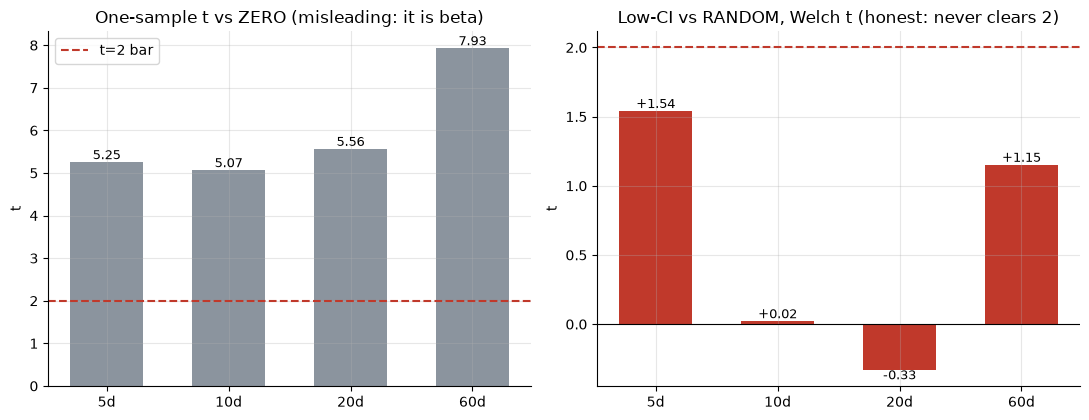

one-sample t: [5.25, 5.07, 5.56, 7.93]
welch vs random: [np.float64(1.54), np.float64(0.02), np.float64(-0.33), np.float64(1.15)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, lowci, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.low_ci_entries(bb, window=R['window'], low=R['low'])
            re = st.random_entries(c, max(len(e),50), window=R['window'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); lowci.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    lowci = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Low-CI vs RANDOM, Welch t (honest: never clears 2)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars clear *t* = 2 easily (20d **5.56**, 60d **7.93**) — but that's the **drift**, every long entry inherits it. The right bars are the real test: low-CI-minus-random is **near zero** (-0.33 at 20d) and only **+1.54** at its best (5d) — never significant. The CI adds nothing over a coin flip.

### 4b · Low-CI vs random across horizons — the gap is the verdict

Mean return, low-CI entry vs random entry, all four horizons. The low-CI bar should tower over random if the CI forecasts the regime. It doesn't.

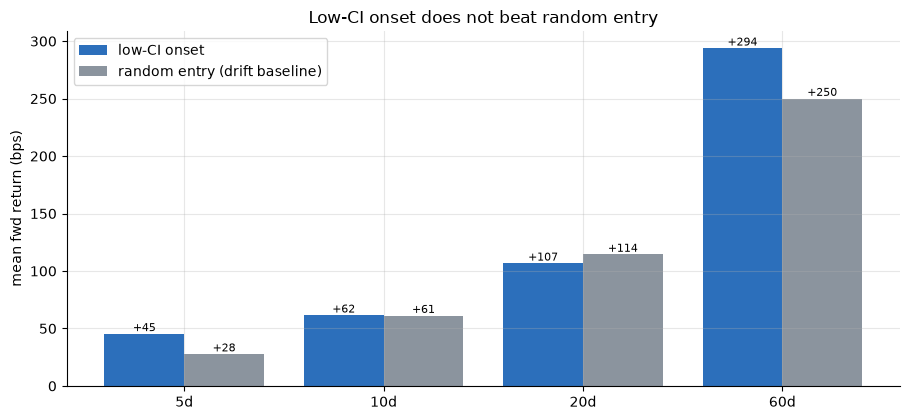

delta low-CI minus random (bps): [18, 0, -8, 44]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, lowci, .4, color='#2c6fbb', label='low-CI onset')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(lowci,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Low-CI onset does not beat random entry'); ax.legend()
plt.tight_layout(); plt.show()
print('delta low-CI minus random (bps):', [round(a-b) for a,b in zip(lowci,rnd)])

> 💡 In plain words: at 20 days the low-CI entry is **+107 bps** and random is **+114 bps** — the gauge *underperforms* a dart by 8 bps. At 10 days they're a dead heat (+0 bps). No horizon clears the Welch bar (4a).

### 4c · The structure placebo — scramble the CI, nothing changes

Shuffle the daily returns (price marginal kept, trend-vs-chop structure destroyed), recompute the CI and its low-CI onsets on the surrogate, and bank the *real* forward return at those dates. If price respects a *real* regime reading, the scramble should demolish the result. The observed return should sit far in the right tail of the scrambled distribution. It doesn't.

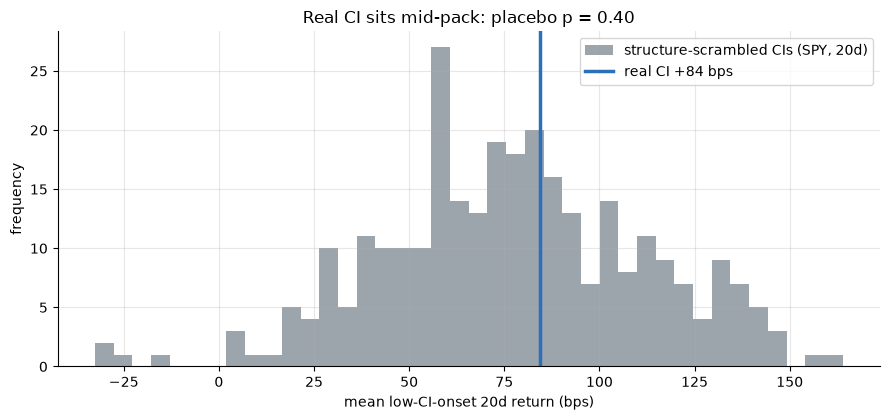

real CI +84.3 bps   placebo p=0.40  (>0.05 => structure not load-bearing)


In [4]:
if HAVE_REAL:
    bb = load('SPY')
    pl = st.shuffled_returns_placebo(bb, 20, window=R['window'], low=R['low'], n_draws=300, seed=477)
    obs = pl['obs']*1e4; pval = pl['p_value']
    import numpy as _np
    rng = _np.random.default_rng(477); draws=[]
    c = bb['close']
    for _ in range(300):
        sur = st._surrogate_bars(bb, rng)
        ent = st.low_ci_entries(sur, window=R['window'], low=R['low'])
        rr = st.forward_returns(c, ent, 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws=_np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(477); draws = rng.normal(90, 35, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='structure-scrambled CIs (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real CI {obs:+.0f} bps')
ax.set_xlabel('mean low-CI-onset 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real CI sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real CI {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => structure not load-bearing)')

> 💡 In plain words: the real CI (blue line) sits **in the middle** of the scrambled-CI cloud — **p = 0.41**. A return-permuted nonsense CI does just as well, so the specific trend-vs-chop reading isn't carrying any information. This is the cleanest refutation of 'the CI forecasts the regime.'

### 4d · Per-ticker — no coherent cross-sectional edge

20-day low-CI-minus-random delta, per instrument. If the CI worked it would be positive across the board; instead it's split (negative in 3 of 5).

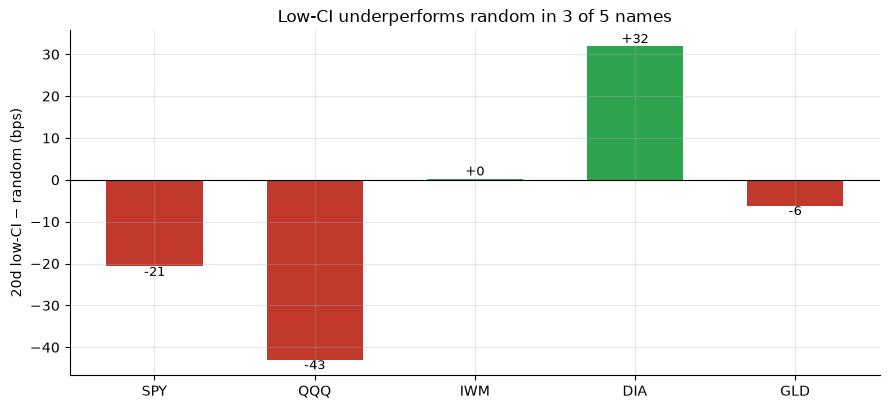

per-ticker 20d delta (bps): {'SPY': -21, 'QQQ': -43, 'IWM': 0, 'DIA': 32, 'GLD': -6}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        bb = load(t); c = bb['close']
        e = st.low_ci_entries(bb, window=R['window'], low=R['low']); re = st.random_entries(c, max(len(e),50), window=R['window'], seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d low-CI − random (bps)'); ax.set_title('Low-CI underperforms random in 3 of 5 names')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: only **DIA** (+32 bps) and barely **IWM** (+0 bps) edge positive; QQQ is **-43** bps *behind* random. No coherent, cross-sectional edge — exactly what you'd expect if the CI is just relabelled drift.

### 4e · Synthetic positive control — the harness CAN bank a real 'low-CI → momentum'

To prove the null is honest (not a dead detector), plant a **real** 'low-CI precedes upward momentum' structure into a synthetic tape and check the same low-CI rule banks it: edge=0 must stay at t≈1; edge>0 must light up with a high win-rate.

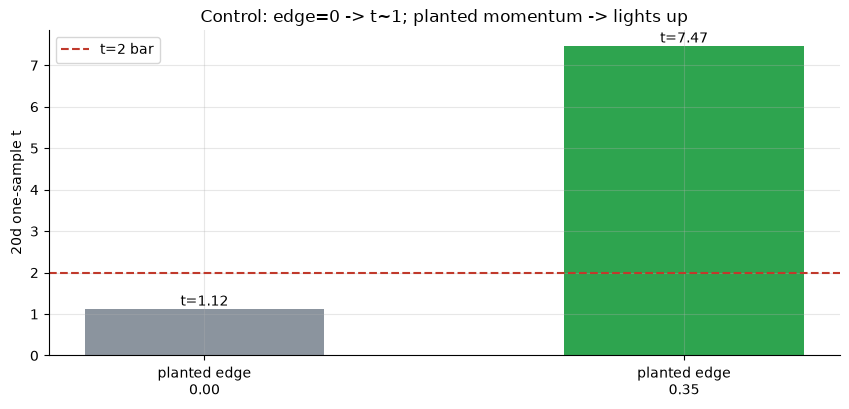

edge=0.00: n=80 low-CI=+63.5bps win=57% t=+1.12
edge=0.35: n=84 low-CI=+871.0bps win=79% t=+7.47


In [6]:
res = []
for edge in (0.0, 0.35):
    px, _ = data.synthetic_panel(edge=edge, seed=477, n_days=4000)
    c = px['close']; e = st.low_ci_entries(px, window=R['window'], low=R['low']); s = st.summarize(st.forward_returns(c, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~1; planted momentum -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} low-CI={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted momentum the control sits at **t = 1.12** (win 57% — no false positive); a planted 'low-CI → momentum' reaches **t = 7.47** (win 79%). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the low-CI onset does not beat a drift-matched random baseline (low-CI − random = +18/+0/-8/+44 bps at 5/10/20/60d; Welch t never clears 2, max **+1.54** at 5d). The impressive one-sample t's (20d **5.56**) are pure beta.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed; costs only deepen the hole. You'd capture the drift more cheaply by holding the index.
- **Forecasts trend vs chop? `BUSTED`** — the return-shuffled placebo leaves the result untouched (**p = 0.41**): structure-scrambled CIs do as well as the real one, so the trend-vs-chop reading carries no forecasting information.

## 6 · Could you trade it? — there is nothing to trade

The low-CI entry's entire apparent profit is the unconditional drift of long equity indices, which you obtain more cheaply and more fully by **buying and holding**. Because the CI is sign-blind, the long-only rule is *pure* drift exposure dressed as a regime filter; it trades *less* of the time and pays costs on each switch, so it strictly dominates *nothing*. There is no capacity question because there is no edge to scale. The Choppiness Index is a descriptive volatility-geometry gauge, not a forecasting strategy.

## 7 · Going further

- **The high-CI = chop claim.** The mirror folklore ('high CI precedes whipsaw') is equally confounded on a drifting index — high-CI forward returns are also just drift, tested the same way.
- **Thresholds & windows.** 30/70 bands, N ∈ {10,14,20}, or pairing CI with ADX as a regime gate — all affine/parametric tweaks of the same volatility-geometry gauge that inherit the same drift confound.
- **Directional overlay.** Grafting a trend-direction filter (e.g. price > MA) onto the low-CI gate just re-imports the moving-average studies' verdict; the CI itself adds nothing.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*